---
## This plot will create "Figure 3"(s) for the paper draft of Feb. '26
##### 2/11/26
---

In [1]:
# kernel: pangeo23

In [2]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats

from coastal_analysis_fns import *

/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [3]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [4]:
def convert_dat_to_pctile(da):
    '''
    8/18/25
    
    Params:
    - da (DataArray) dims = staid, time
    
    returns:
    - pctile_da_out (xr.dataArray) same dims, data = transformed to percentile, within each station & day of year. 
    '''
    
    # np.arrays for raw data and output percentile-d data.
    dat = da.data
    pctile_dat = np.zeros(shape=dat.shape) * np.nan
    
    # for each day of the year, transform each station's data into percentile relative to that day-of-yr
    for d in range(1, 367):

        # mask to select day of year
        dayofyear_mask = (da.time.dt.dayofyear==d)
        ndays = np.sum(dayofyear_mask).item()

        # compute percentile value for each entry
        h22 = stats.rankdata(dat[:, dayofyear_mask], axis=1)
        h22_pct = (h22/ndays) * 100 # converting rank to percentile

        # save that day-of-year's percentile data
        pctile_dat[:, dayofyear_mask] = h22_pct
        
    # return
    pctile_da_out = xr.DataArray(pctile_dat, dims=da.dims, coords=da.coords)
    
    return pctile_da_out

In [5]:
def make_lagged_onsetmask1D(dat, lag):
    '''
    This function takes the mhw_onsets array/mask and returns one shifted over "lag" number of days
    
    params:
        dat (np.array or xr.dataArray) the mask you want to shift
        lag (int) the number of days/spaces you want to shift. negative = backwards/before, positive=forwards/after
        
    returns: lag_arr
    
    10/14/25 - adapted for 1-dimensional input data
    '''
    
    
    # empty array
    lag_arr = np.zeros(shape=dat.shape).astype(bool)
    abslag = abs(lag)

    # if a negative lag (aka before event onset)
    if lag < 0:

        lag_arr[:lag] = dat[abslag:]

    elif lag > 0:

        lag_arr[lag:] = dat[:(-lag)]
        
    elif lag==0:
        
        lag_arr = dat # self-explanatory?
        
    return lag_arr

In [6]:
def make_lagged_onsetmask(dat, lag):
    '''
    This function takes the mhw_onsets array/mask and returns one shifted over "lag" number of days
    
    params:
        dat (np.array or xr.dataArray) the mask you want to shift
        lag (int) the number of days/spaces you want to shift. negative = backwards/before, positive=forwards/after
        
    returns: lag_arr
    
    1/30/25
    '''
    
    
    # empty array
    lag_arr = np.zeros(shape=dat.shape).astype(bool)
    abslag = abs(lag)

    # if a negative lag (aka before event onset)
    if lag < 0:

        lag_arr[:, :lag] = dat[:, abslag:]

    elif lag > 0:

        lag_arr[:, lag:] = dat[:, :(-lag)]
        
    elif lag==0:
        lag_arr = dat
        
    return lag_arr

def bin_lat_scatters(latbins, lats, dat):
    
    binned_means = []
    bin_midpoints = []
    bin_n_obs = []

    i = 0

    while i < len(latbins)-1:

        bot_bin = latbins[i]
        top_bin = latbins[i+1]

    #    print(bot_bin, top_bin)

        binmask = (lats >= bot_bin) * (lats < top_bin)

        binned_means.append(np.nanmean(dat[binmask]))
        bin_midpoints.append(((bot_bin+top_bin)/2))
        bin_n_obs.append(np.sum(binmask))

        i += 1
        
    return binned_means, bin_midpoints, bin_n_obs

def prep_global_binned_leadlags(da, event_onsets, window, latbins):

    '''
    Function-izing code from earlier work...
    
    This function creates binned/lagged dataArrays of a desired variable centered on desired events, binned by lat.
    
    Params:
    - da (xr.dataArray) the input variable. dims = [staid, time]
    - event_onsets (xr.dataArray) bool indices to the events of interest. dims = [staid, time]
    - window (int) number of days before and after event onset which you are interested in binning
    - latbins (np.array) latitude bins to use
    
    Returns:
    - var_bin_lag_da (xr.Da) variable, averaged across various lags and binned by lat. dims = [lat bin, event-day]
    
    '''

    # these will hold the MHW evolutions in a different form. shape = [lat bin, lag day]
    bin_lag_profile_arr = np.zeros(shape=((len(latbins)-1), ((window*2)+1)))

    # counter var
    i = 0

    # will take lags from -w days prior to mhw event thru +w days 
    for l in range(-window, (window+1)):

        # make a mask to select all days with lag=l rel. to mhw onsets
        if not l==0:
            lagmhwmask = make_lagged_onsetmask(dat=event_onsets, lag=l)
        elif l==0: 
            lagmhwmask = event_onsets

        # sel avg. <var> at every station at that <event> lag
        var_lag_means = da.where(lagmhwmask).mean(dim='time').to_numpy()

        # bin by lat
        var_lag_means_binned, bin_midpoints, bin_nobs = bin_lat_scatters(latbins=latbins, lats=gdf['LAT'].to_numpy(), dat=var_lag_means)

        # add to arrays
        bin_lag_profile_arr[:, i] = var_lag_means_binned

        i+=1

    # put into dataArray
    bin_lag_profile_da = xr.DataArray(bin_lag_profile_arr, dims=['lat bin', 'day'], coords={'lat bin':bin_midpoints, 'day':np.array(range(-window, (window+1)))})

    return bin_lag_profile_da                      

In [7]:
script = 'Fig3_submissionFeb26.ipynb'

In [8]:
# dataframe with the stations we are using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

In [9]:
# open geophysical data

# MHW
hw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.marineheatwaves_roll11.nc') # 11 DAY ROLLING!!!
mhw_mask = hw_ds.MHW
mhw_onset_mask = hw_ds.MHW_onsets.astype(bool)

# thw
thw_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.heatwaves.nc')
thw_mask = thw_ds.THW
thw_onset_mask = thw_ds.THW_onsets.astype(bool)

# station var's
tx_det_da_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.tx.detrend_stanom.roll11.nc').Tx # new file 11/21
td_det_da_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.td.detrend_stanom.roll11.nc').Td # new file 11/21
slp_det_da_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.slp.detrend_stanom.roll11.nc').slp # new file 11/21
windspeed_det_da_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.windspeeds.detrend_stanom.roll11.nc').windspeeds # new file 11/21

#  SST 
sst_det_da_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.sst.detrend_stanom.roll11.nc').sst.sel(time=slice('1990-01-01', '2023-12-31')) # new file 11/21

# open heatflux data (anomalies, over the stations)
slhf15_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.slhf.detrend_stanom.roll11.nc').slhf
sshf15_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.sshf.detrend_stanom.roll11.nc').sshf
ssr15_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.ssr.detrend_stanom.roll11.nc').ssr
str15_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.1.5deg.str.detrend_stanom.roll11.nc').str

# open heat fluxes over land as well
slhfSTA_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.OverStations.slhf.detrend_stanom.roll11.nc').slhf
sshfSTA_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.OverStations.sshf.detrend_stanom.roll11.nc').sshf
ssrSTA_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.OverStations.ssr.detrend_stanom.roll11.nc').ssr
strSTA_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.OverStations.str.detrend_stanom.roll11.nc').str

# mixed layer depth
mld_da_st = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.mld.detrend_stanom.roll11.nc').mld

# season masks
szn_ds = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/ALLSTATIONS.warm_cold_seasons.nc')
warmszn_mask = szn_ds.warmszn_mask.astype(bool)
coldszn_mask = szn_ds.coldszn_mask.astype(bool)

In [10]:
# T profile data
tprofile_ds = xr.open_dataset('/home/nsiegert/projects/coastal_sst/data/t_profiles/GlobalMean_STD_Tprofiles_forFig.nc')

varname_outline = 'globalmean_T_X_S'
event_types = ['mhw', 'thw', 'con']
seasons = ['w', 'c']
plevels = tprofile_ds.level

# analysis

In [11]:
# gather concurrent event onsets
concurrent_ev_mask = (mhw_mask * thw_mask)

# onsets are days where there is no concurrent event (=0), and the next day = 1
concurrent_ev_onsetmaskPre = (concurrent_ev_mask==0).data[:, :-1] * concurrent_ev_mask.data[:, 1:] # and have to drop the last day of ds from analysis. This gets us an onset mask for the second day of the ds onwards. 
concurrent_ev_onsetmask = np.zeros(shape=concurrent_ev_mask.shape)
concurrent_ev_onsetmask[:, 1:] = concurrent_ev_onsetmaskPre # fill in the 0 on the first day0 (which can't be an onset b/c we don't know the status of the day prior)

concurrent_ev_onsetmask_da = xr.DataArray(concurrent_ev_onsetmask, dims=concurrent_ev_mask.dims, coords=concurrent_ev_mask.coords)

In [12]:
## warm-season lead-lags with ONE GLOBAL BIN, using standardized anomaly ##

In [13]:
# these are the different data/variables that we will be binning
input_dat_toBin_list = [sst_det_da_st, tx_det_da_st, td_det_da_st, slp_det_da_st.where(np.isfinite(slp_det_da_st)), windspeed_det_da_st, slhf15_st, sshf15_st, ssr15_st, str15_st, slhfSTA_st, sshfSTA_st, ssrSTA_st, strSTA_st]

# need to nan and inf-mask the SLP data for some reason. (12/1)

In [14]:
%%time

# lead-lags with ONE GLOBAL BIN

# lead-lags for warm-season MHW events (1 lat bin aka global mean)
eventUse = xr.where((hw_ds.MHW_onsets*np.logical_not(thw_ds.THW)*warmszn_mask), True, False).data 
ww = 30
lbins = np.array([-60, 70])

MHW_binnedvars_list = []

for indat in input_dat_toBin_list:
    
    MHW_binnedvars_list.append(prep_global_binned_leadlags(da=indat, event_onsets=eventUse, window=ww, latbins=lbins))

    
# MLD... (need to trim the event selection)
eventUseTrim = xr.where((hw_ds.MHW_onsets*np.logical_not(thw_ds.THW)*warmszn_mask), True, False).sel(time=slice('1993-01-01', '2021-06-30'))
mld_da_st['time'] = eventUseTrim.time
eventUseTrimDat = eventUseTrim.data

MHW_binnedvars_list.append(prep_global_binned_leadlags(da=mld_da_st, event_onsets=eventUseTrimDat, window=ww, latbins=lbins))

CPU times: user 2min 13s, sys: 3min 46s, total: 6min
Wall time: 6min


In [15]:
%%time

# lead-lags with ONE GLOBAL BIN

# lead-lags for warm-season THW events (1 lat bin aka global mean)
eventUse = xr.where((thw_ds.THW_onsets*np.logical_not(hw_ds.MHW)*warmszn_mask), True, False).data 
ww = 30
lbins = np.array([-60, 70])

THW_binnedvars_list = []

for indat in input_dat_toBin_list:
    
    THW_binnedvars_list.append(prep_global_binned_leadlags(da=indat, event_onsets=eventUse, window=ww, latbins=lbins))

    
# MLD... (need to trim the event selection)
eventUseTrim = xr.where((thw_ds.THW_onsets*np.logical_not(hw_ds.MHW)*warmszn_mask), True, False).sel(time=slice('1993-01-01', '2021-06-30'))
mld_da_st['time'] = eventUseTrim.time
eventUseTrimDat = eventUseTrim.data

THW_binnedvars_list.append(prep_global_binned_leadlags(da=mld_da_st, event_onsets=eventUseTrimDat, window=ww, latbins=lbins))

CPU times: user 2min 11s, sys: 3min 40s, total: 5min 52s
Wall time: 5min 52s


In [16]:
%%time

# lead-lags with ONE GLOBAL BIN

# lead-lags for warm-season concurrent events (1 lat bin aka global mean)
eventUse = xr.where((concurrent_ev_onsetmask_da*warmszn_mask), True, False).data 
ww = 30
lbins = np.array([-60, 70])

CON_binnedvars_list = []

for indat in input_dat_toBin_list:
    
    CON_binnedvars_list.append(prep_global_binned_leadlags(da=indat, event_onsets=eventUse, window=ww, latbins=lbins))

    
# MLD... (need to trim the event selection)
eventUseTrim = xr.where((concurrent_ev_onsetmask_da*warmszn_mask), True, False).sel(time=slice('1993-01-01', '2021-06-30'))
mld_da_st['time'] = eventUseTrim.time
eventUseTrimDat = eventUseTrim.data

CON_binnedvars_list.append(prep_global_binned_leadlags(da=mld_da_st, event_onsets=eventUseTrimDat, window=ww, latbins=lbins))

CPU times: user 2min 11s, sys: 3min 39s, total: 5min 50s
Wall time: 5min 50s


In [17]:
print('ready to plot standardized!')

ready to plot standardized!


In [18]:
print('DO NOT RESTART THE KERNEL!')

DO NOT RESTART THE KERNEL!


# plot

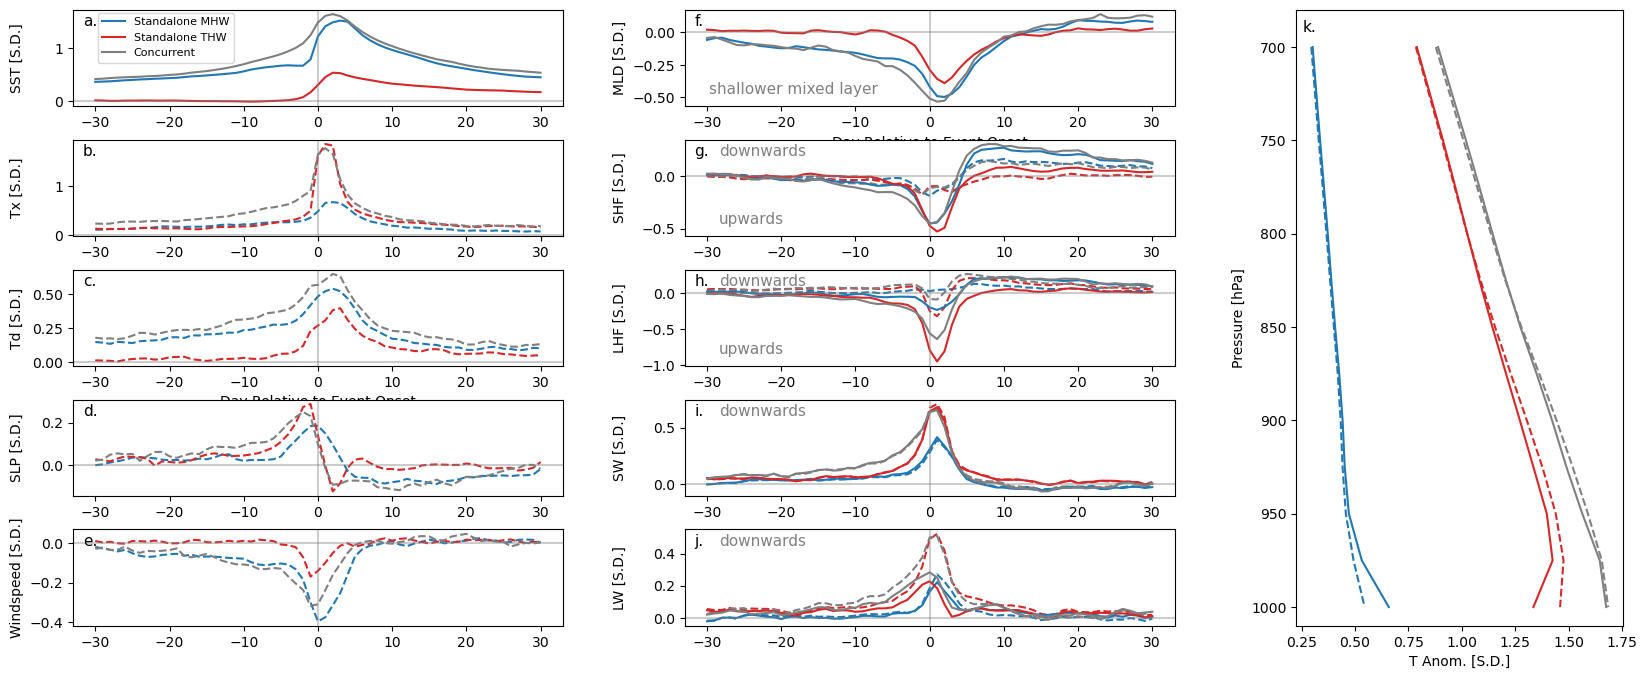

In [19]:
# set up figure
nrows = 5
ncols = 3
fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig, width_ratios=[1.5, 1.5, 1]) 
gs.update(wspace=0.28, hspace=0.35)


## loop thru and plot variable progressions
row_label_list = ['SST', 'Tx', 'Td', 'SLP', 'Windspeed', 'MLD', 'SHF', 'LHF', 'SW', 'LW']
letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']

pltctr = 0
r = 0
c = 0

axes = []

for pltctr in range(10):
    
    # add ax
    ax = fig.add_subplot(gs[r, c])        
    
    # set linestyle (using dashes for measurements taken over station, solid line for over ocean)
    if pltctr in [1, 2, 3, 4]:
        lls = '--'
    else:
        lls = '-'

    # plot stuff - pick the data to plot
    MHW2plot = MHW_binnedvars_list[pltctr]
    THW2plot = THW_binnedvars_list[pltctr]
    con2plot = CON_binnedvars_list[pltctr]
    
    # manually specify what to plot for mixed layer depth so that it's before the heat fluxes
    if pltctr==5:
        MHW2plot = MHW_binnedvars_list[-1]
        THW2plot = THW_binnedvars_list[-1]
        con2plot = CON_binnedvars_list[-1]

    # for the heatfluxes:
    if pltctr>5:    
        MHW2plot = MHW_binnedvars_list[pltctr-1] # now i have to shift b/c I plotted MLD before heat fluxes but HF's are saved earlier
        THW2plot = THW_binnedvars_list[pltctr-1]
        con2plot = CON_binnedvars_list[pltctr-1]
        
        MHW2plotSTA = MHW_binnedvars_list[pltctr+3] # the STA var's are saved 4 spaces on from the over ocean versions (why did I do that)
        THW2plotSTA = THW_binnedvars_list[pltctr+3]
        con2plotSTA = CON_binnedvars_list[pltctr+3]
        
        MHW2plotSTA.plot(ax=ax, label='Standalone MHW', color='tab:blue', ls='--')
        THW2plotSTA.plot(ax=ax, label='Standalone THW', color='tab:red', ls='--')
        con2plotSTA.plot(ax=ax, label='Concurrent', color='tab:grey', ls='--')
        
        ax.text(s='downwards', x=0.07, y=0.83, transform=ax.transAxes, ha='left', fontsize=11, color='grey')

    # plot the data
    MHW2plot.plot(ax=ax, label='Standalone MHW', color='tab:blue', ls=lls)
    THW2plot.plot(ax=ax, label='Standalone THW', color='tab:red', ls=lls)
    con2plot.plot(ax=ax, label='Concurrent', color='tab:grey', ls=lls)
    
        
    # axis cosmetics
    ax.set(xlabel='', ylabel='{} [S.D.]'.format(row_label_list[pltctr]), title='') # for now
    ax.axvline(color='grey', alpha=0.4)
    ax.text(s='{}.'.format(letters[pltctr]), x=0.02, y=0.83, transform=ax.transAxes, ha='left', fontsize=11)
    ax.axhline(color='grey', alpha=0.4)
    
    # if it's the first plot, I want to save the legend elements
    handles1, labels1 = ax.get_legend_handles_labels()
    
    # update plot counter, row and column at the end of this list
    axes.append(ax)
    pltctr += 1
    r += 1
    
    if r==nrows:
        r = 0
        c += 1
    
# axis legends, labels, descriptive text





axes[0].legend(loc=(0.051, 0.45), fontsize=8)




axes[2].set(xlabel='Day Relative to Event Onset')
axes[5].set(xlabel='Day Relative to Event Onset')        
axes[5].text(s='shallower mixed layer', x=0.05, y=0.13, transform=axes[5].transAxes, ha='left', fontsize=11, color='grey')
axes[6].text(s='upwards', x=0.07, y=0.13, transform=axes[6].transAxes, ha='left', fontsize=11, color='grey')
axes[7].text(s='upwards', x=0.07, y=0.13, transform=axes[7].transAxes, ha='left', fontsize=11, color='grey')

    
## T-Profile axis
ax = fig.add_subplot(gs[:, 2])

for evtype in event_types:
    
    if evtype == 'mhw':
        cc = 'tab:blue'
    elif evtype == 'thw':
        cc = 'tab:red'
    elif evtype == 'con':
        cc = 'grey'
        
    vname1 = 'globalmean_T_{}_w'.format(evtype)
    vname2 = 'globalmean_T_STA_{}_w'.format(evtype)
    
    ax.plot(tprofile_ds[vname1], plevels, color=cc, ls='-') # plot T profile for that event over ocean
    ax.plot(tprofile_ds[vname2], plevels, color=cc, ls='--') # plot T profile for that event over station
    
    ax.invert_yaxis()
    
# cosmetics (axis labels, letter to ID subplot, shift ax lim down a bit so letter doesn't overlap data)
ax.set(ylabel='Pressure [hPa]', xlabel='T Anom. [S.D.]')
ax.text(s='k.', x=0.02, y=0.965, transform=ax.transAxes, ha='left', fontsize=11)
ax.set_ylim(1010.0, 680.0)


# Align the y-labels
fig.align_ylabels(axes) # You can pass a specific list of axes or leave empty to align all

# time & script
# now = datetime.now() # get datetime
# fig.text(0.85, 0.015, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='x-small', ha='right') # text
# fig.text(0.85, 0.005, script, ha='right', fontsize='x-small')

# SAVE FIGURE
# plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_submission_2.2026/Fig3_coastalsst_grl_2_26.png', format='png', bbox_inches='tight')

plt.show()

In [25]:
print('hello')

hello
